<h1 style="color:#4A0072; border-bottom:3px solid #6A1B9A; padding-bottom:8px;"> Reconhecimento de Gestos em Tempo Real </h1>

<h2 style="color:#4A0072;">📖 Como Funciona o Reconhecimento de Gestos?</h2>

O **reconhecimento de gestos** é uma tarefa avançada da Visão Computacional que combina *detecção de mãos*, *rastreamento de landmarks* (pontos-chave) e *classificação de gestos* em um único pipeline. Diferente da detecção de objetos genérica, o reconhecedor de gestos entende a **pose da mão** e interpreta o significado do gesto.

<h3 style="color:#6A1B9A;">🔧 As Ferramentas que Vamos Usar</h3>
<ul>
<li><b>OpenCV:</b> Biblioteca de Visão Computacional para <i>captura de vídeo da webcam</i>, manipulação de frames e exibição de resultados em tempo real.</li>
<li><b>MediaPipe Gesture Recognizer (Google):</b> Modelo pré-treinado do Google que detecta mãos, rastreia 21 pontos-chave (landmarks) e classifica gestos automaticamente.</li>
</ul>

<h3 style="color:#6A1B9A;">🧠 O Modelo: Gesture Recognizer (float16)</h3>
<ul>
<li><b>Arquitetura:</b> Combina um detector de mãos, um modelo de landmarks (21 pontos por mão) e um classificador de gestos em um único bundle <code>.task</code>.</li>
<li><b>Precisão float16:</b> Versão com pesos em <b>ponto flutuante de 16 bits</b>, equilibrando precisão e eficiência.</li>
<li><b>Gestos reconhecidos (8 categorias):</b></li>
</ul>

| Gesto | Descrição |
|---|---|
| ✊ `Closed_Fist` | Punho fechado |
| 🖐️ `Open_Palm` | Palma aberta |
| ☝️ `Pointing_Up` | Dedo indicador apontando para cima |
| 👍 `Thumb_Up` | Joinha para cima |
| 👎 `Thumb_Down` | Joinha para baixo |
| ✌️ `Victory` | Sinal de vitória / paz |
| 🤟 `ILoveYou` | Sinal "eu te amo" em libras |
| ❌ `None` | Nenhum gesto reconhecido |

<h3 style="color:#6A1B9A;">⚙️ O Pipeline</h3>
<ol>
<li>A <b>webcam</b> captura frames continuamente (via OpenCV)</li>
<li>Cada frame é convertido para o formato <b>MediaPipe Image</b> (RGB)</li>
<li>O <b>timestamp</b> do frame é calculado via <code>cv2.getTickCount()</code></li>
<li>O <b>Gesture Recognizer</b> analisa o frame e retorna: landmarks da mão, lateralidade (esq/dir) e gesto reconhecido</li>
<li>Desenhamos os <b>landmarks</b>, as <b>conexões entre pontos</b> e o <b>rótulo do gesto</b> sobre o frame</li>
<li>O resultado é exibido em uma <b>janela em tempo real</b></li>
</ol>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #6A1B9A; margin:10px 0;">
💡 <b>Dica:</b> O MediaPipe Gesture Recognizer faz tudo internamente — detecção da mão, extração de landmarks e classificação do gesto — com poucas linhas de código!
</div>

<br>
<h2 style="color:#4A0072;">📥 Download do Modelo Pré-Treinado</h2>

Vamos baixar o modelo **Gesture Recognizer** na versão **float16** diretamente dos servidores do Google.

O arquivo `.task` será salvo na mesma pasta deste notebook:

In [1]:
import urllib.request
import os

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/1/gesture_recognizer.task"
MODEL_PATH = "gesture_recognizer.task"

if not os.path.exists(MODEL_PATH):
    print("Baixando o modelo Gesture Recognizer (float16)...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f"Modelo salvo em: {MODEL_PATH}")
else:
    print(f"Modelo já existe: {MODEL_PATH}")

print(f"Tamanho do arquivo: {os.path.getsize(MODEL_PATH) / (1024*1024):.1f} MB")

Modelo já existe: gesture_recognizer.task
Tamanho do arquivo: 8.0 MB


<br>
<h2 style="color:#4A0072;">🔧 Imports e Configuração</h2>

Importamos as bibliotecas e definimos os aliases do MediaPipe Tasks para o reconhecedor de gestos:

In [2]:
import cv2
import mediapipe as mp
import numpy as np
import csv
import time

# Aliases do MediaPipe Tasks para Gesture Recognizer
BaseOptions = mp.tasks.BaseOptions
GestureRecognizer = mp.tasks.vision.GestureRecognizer
GestureRecognizerOptions = mp.tasks.vision.GestureRecognizerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

print("Imports carregados com sucesso!")

Imports carregados com sucesso!


<br>
<h2 style="color:#4A0072;">🖐️ Reconhecimento de Gestos em Tempo Real com a Webcam</h2>

Agora vem a parte principal! O código abaixo utiliza o **Gesture Recognizer** do MediaPipe:

<h3 style="color:#6A1B9A;">Passo a passo do loop:</h3>
<ol>
<li><b>Configura</b> o reconhecedor com detecção de até 2 mãos e abre a webcam com resolução 640×480</li>
<li><b>Captura</b> e <b>espelha</b> cada frame (<code>cv2.flip</code>)</li>
<li><b>Converte</b> BGR → RGB e cria o <code>mp.Image</code></li>
<li><b>Calcula o timestamp</b> com <code>cv2.getTickCount()</code></li>
<li><b>Reconhece</b> gestos com <code>recognize_for_video()</code></li>
<li><b>Desenha</b> landmarks (21 pontos), conexões entre eles e o rótulo do gesto reconhecido</li>
<li><b>Exibe</b> o resultado — pressione <b>Q</b> para sair</li>
</ol>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #6A1B9A; margin:10px 0;">
⚠️ <b>Importante:</b> Pressione a tecla <b>Q</b> para encerrar a janela de vídeo. Se a janela travar, reinicie o kernel do notebook.
</div>

In [3]:
# --- Cores para desenhar (em BGR) ---
COR_LANDMARK = (154, 27, 106)       # roxo (#6A1B9A em BGR)
COR_CONEXAO = (200, 120, 180)       # roxo claro
COR_TEXTO_FUNDO = (72, 0, 74)       # roxo escuro (#4A0072 em BGR)
COR_TEXTO = (255, 255, 255)         # branco
COR_GESTO_FUNDO = (154, 27, 106)    # roxo para fundo do gesto

# Mapeamento de gestos para emojis
EMOJI_GESTOS = {
    "Closed_Fist": "Punho Fechado",
    "Open_Palm": "Palma Aberta",
    "Pointing_Up": "Apontando p/ Cima",
    "Thumb_Up": "Joinha p/ Cima",
    "Thumb_Down": "Joinha p/ Baixo",
    "Victory": "Vitoria / Paz",
    "ILoveYou": "Eu Te Amo (Libras)",
    "None": "Nenhum Gesto",
}

# Lista estática de conexões da mão
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (0, 17), (17, 18), (18, 19), (19, 20)
]

def desenhar_landmarks_mao(frame, hand_landmarks_list):
    """Desenha os 21 landmarks e conexões de cada mão detectada."""
    h, w, _ = frame.shape
    for hand_landmarks in hand_landmarks_list:
        pontos = []
        for lm in hand_landmarks:
            cx, cy = int(lm.x * w), int(lm.y * h)
            pontos.append((cx, cy))

        # Desenhar conexões entre landmarks
        for conexao in HAND_CONNECTIONS:
            p1 = pontos[conexao[0]]
            p2 = pontos[conexao[1]]
            cv2.line(frame, p1, p2, COR_CONEXAO, 2)

        # Desenhar cada ponto (landmark)
        for (cx, cy) in pontos:
            cv2.circle(frame, (cx, cy), 5, COR_LANDMARK, -1)
            cv2.circle(frame, (cx, cy), 7, COR_TEXTO, 1)

    return frame


def desenhar_resultados(frame, resultado):
    """Desenha landmarks, conexões e rótulos de gestos no frame."""
    if not resultado.gestures:
        return frame

    # Desenhar landmarks de todas as mãos
    if resultado.hand_landmarks:
        frame = desenhar_landmarks_mao(frame, resultado.hand_landmarks)

    # Para cada mão detectada, exibir o gesto reconhecido
    h, w, _ = frame.shape
    if resultado.hand_landmarks:
        for i, (gesto_list, mao_list) in enumerate(zip(resultado.gestures, resultado.handedness)):
            gesto = gesto_list[0]
            mao = mao_list[0]

            nome_gesto = gesto.category_name
            confianca = gesto.score
            lateralidade = mao.category_name  # "Left" ou "Right"

            # Traduzir nome do gesto
            descricao = EMOJI_GESTOS.get(nome_gesto, nome_gesto)
            texto = f"{descricao} ({confianca:.0%})"
            texto_mao = f"Mao: {lateralidade}"

            # Posição do texto (canto superior, uma linha por mão)
            y_base = 40 + i * 80

            # Fundo do rótulo do gesto
            (tw, th), _ = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
            cv2.rectangle(frame, (10, y_base - th - 10), (10 + tw + 16, y_base + 8), COR_GESTO_FUNDO, -1)
            cv2.putText(frame, texto, (18, y_base), cv2.FONT_HERSHEY_SIMPLEX, 0.9, COR_TEXTO, 2)

            # Lateralidade da mão
            (tw2, th2), _ = cv2.getTextSize(texto_mao, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
            cv2.putText(frame, texto_mao, (18, y_base + 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COR_CONEXAO, 2)

    return frame


# --- Configuração do reconhecedor de gestos ---
options = GestureRecognizerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

# --- Webcam ---
cap = cv2.VideoCapture(0)

# Definindo a resolução
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Iniciando reconhecimento de gestos... Pressione 'q' para sair.")

with GestureRecognizer.create_from_options(options) as recognizer:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("Falha ao capturar imagem da câmera")
            break

        # Espelhar e converter BGR -> RGB
        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

        # Timestamp em milissegundos (necessário para o modo VIDEO)
        timestamp_ms = int(cv2.getTickCount() / cv2.getTickFrequency() * 1000)

        # Realiza o reconhecimento de gestos
        resultado = recognizer.recognize_for_video(mp_image, timestamp_ms)

        # Desenha os resultados no frame original
        frame_anotado = desenhar_resultados(frame, resultado)

        cv2.imshow('Reconhecimento de Gestos - MediaPipe', frame_anotado)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
print("Webcam encerrada.")

Iniciando reconhecimento de gestos... Pressione 'q' para sair.
Webcam encerrada.


<br>
<h1 style="color:#4A0072; border-bottom:3px solid #6A1B9A; padding-bottom:8px;">📊 Coleta de Dataset de Gestos Customizados</h1>

<h2 style="color:#4A0072;">📖 Como Funciona a Coleta de Dados?</h2>

Para treinar nosso **próprio modelo** de reconhecimento de gestos, precisamos primeiro criar um **dataset** com exemplos de cada gesto. O script abaixo faz exatamente isso:

<h3 style="color:#6A1B9A;">⚙️ O Processo</h3>
<ol>
<li>Você define o <b>nome do gesto</b> (<code>LABEL_ATUAL</code>) e a <b>quantidade de amostras</b> desejada</li>
<li>A webcam abre e mostra os landmarks em tempo real</li>
<li>Ao pressionar <b>S</b>, inicia uma <b>contagem regressiva de 3 segundos</b> para que você posicione as mãos</li>
<li>Após o cooldown, a <b>gravação começa automaticamente</b> e cada frame com mão detectada é salvo no CSV</li>
<li>Pressione <b>P</b> para pausar e <b>Q</b> para encerrar</li>
</ol>

<h3 style="color:#6A1B9A;">🤝 Suporte a Gestos com 2 Mãos</h3>

O dataset suporta **gestos com 1 ou 2 mãos** (ex: coração com as duas mãos). Cada linha do CSV contém espaço para **2 mãos**:

| Colunas | Conteúdo |
|---|---|
| `num_hands` | Quantas mãos foram detectadas (1 ou 2) |
| `hand1_handedness` | Lateralidade da mão 1 (0=Left, 1=Right) |
| `hand1_x0` ... `hand1_z20` | 63 coordenadas (x, y, z) dos 21 landmarks da mão 1 |
| `hand2_handedness` | Lateralidade da mão 2 (0=Left, 1=Right) — 0 se ausente |
| `hand2_x0` ... `hand2_z20` | 63 coordenadas da mão 2 — tudo 0 se ausente |
| `label` | Nome do gesto (target) |

**Total:** 129 colunas (1 + 1 + 63 + 1 + 63 + label)

<h3 style="color:#6A1B9A;">🔄 Fluxo Recomendado</h3>
<ol>
<li>Defina <code>LABEL_ATUAL = "Coracao"</code> → rode → faça o gesto → colete 200 amostras</li>
<li>Altere <code>LABEL_ATUAL = "Hang_Loose"</code> → rode novamente (o CSV faz <b>append</b>)</li>
<li>Repita para cada gesto que desejar</li>
</ol>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #6A1B9A; margin:10px 0;">
💡 <b>Dica:</b> Quanto mais amostras por gesto, melhor! Tente variar a posição e distância da mão em relação à câmera para tornar o modelo mais robusto.
</div>

<br>
<h2 style="color:#4A0072;">⚙️ Configuração da Coleta</h2>

Altere o `LABEL_ATUAL` para o nome do gesto que deseja coletar e rode a célula seguinte:

In [40]:
# ============================================================
# ⚙️ CONFIGURAÇÃO - Altere aqui antes de cada sessão de coleta
# ============================================================

LABEL_ATUAL = "punho fechado"           # Nome do gesto que será gravado
CSV_PATH = "gestures_dataset.csv"                                      # Arquivo CSV (faz append, não sobrescreve)
AMOSTRAS_POR_SESSAO = 800                                              # Quantos frames gravar por execução
COOLDOWN_SEGUNDOS = 3                                                  # Tempo de espera antes de começar a gravar

print(f"Configuração:")
print(f"  Gesto: {LABEL_ATUAL}")
print(f"  Arquivo: {CSV_PATH}")
print(f"  Amostras: {AMOSTRAS_POR_SESSAO}")
print(f"  Cooldown: {COOLDOWN_SEGUNDOS}s")

Configuração:
  Gesto: punho fechado
  Arquivo: gestures_dataset.csv
  Amostras: 800
  Cooldown: 3s


<br>
<h2 style="color:#4A0072;">🎥 Coletor de Dados com Webcam</h2>

<h3 style="color:#6A1B9A;">Controles:</h3>
<ul>
<li><b>S</b> — Inicia contagem de 3s e começa a gravar</li>
<li><b>P</b> — Pausa a gravação</li>
<li><b>Q</b> — Encerra e salva</li>
</ul>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #6A1B9A; margin:10px 0;">
⚠️ <b>Importante:</b> Posicione suas mãos no gesto desejado <b>durante</b> a contagem regressiva. A gravação <b>só começa</b> quando o countdown terminar!
</div>

In [41]:
def gerar_cabecalho_csv():
    """Gera os nomes das colunas do CSV."""
    colunas = ["num_hands"]
    for mao_idx in [1, 2]:
        colunas.append(f"hand{mao_idx}_handedness")
        for lm_idx in range(21):
            colunas.extend([
                f"hand{mao_idx}_x{lm_idx}",
                f"hand{mao_idx}_y{lm_idx}",
                f"hand{mao_idx}_z{lm_idx}"
            ])
    colunas.append("label")
    return colunas


def extrair_features_mao(hand_landmarks, handedness_name):
    """Extrai as features de uma mão: [handedness, x0, y0, z0, ..., x20, y20, z20]"""
    handedness_val = 0 if handedness_name == "Left" else 1
    features = [handedness_val]
    for lm in hand_landmarks:
        features.extend([lm.x, lm.y, lm.z])
    return features  # 1 + 63 = 64 valores


def mao_vazia():
    """Retorna features zeradas para quando não há segunda mão."""
    return [0] + [0.0] * 63  # 64 zeros


def extrair_linha_csv(resultado, label):
    """Extrai uma linha completa do CSV a partir do resultado do MediaPipe."""
    if not resultado.hand_landmarks:
        return None

    num_maos = len(resultado.hand_landmarks)

    # Mão 1
    hand1_name = resultado.handedness[0][0].category_name
    hand1_features = extrair_features_mao(resultado.hand_landmarks[0], hand1_name)

    # Mão 2 (ou zeros se não existir)
    if num_maos >= 2:
        hand2_name = resultado.handedness[1][0].category_name
        hand2_features = extrair_features_mao(resultado.hand_landmarks[1], hand2_name)
    else:
        hand2_features = mao_vazia()

    linha = [num_maos] + hand1_features + hand2_features + [label]
    return linha


# --- Verificar se o CSV já existe (para decidir se grava cabeçalho) ---
csv_existe = os.path.exists(CSV_PATH)

# --- Configuração do reconhecedor ---
options_coleta = GestureRecognizerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

# --- Webcam ---
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

# --- Estado da coleta ---
gravando = False
em_cooldown = False
cooldown_inicio = 0
contagem_amostras = 0
dados_coletados = []

print(f"=== COLETOR DE DATASET ===")
print(f"Gesto: '{LABEL_ATUAL}' | Meta: {AMOSTRAS_POR_SESSAO} amostras")
print(f"Teclas: [S] Iniciar (com {COOLDOWN_SEGUNDOS}s de cooldown) | [P] Pausar | [Q] Encerrar")
print("")

with GestureRecognizer.create_from_options(options_coleta) as recognizer:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("Falha ao capturar imagem da câmera")
            break

        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        timestamp_ms = int(cv2.getTickCount() / cv2.getTickFrequency() * 1000)

        resultado = recognizer.recognize_for_video(mp_image, timestamp_ms)

        # Desenhar landmarks (visual feedback)
        if resultado.hand_landmarks:
            frame = desenhar_landmarks_mao(frame, resultado.hand_landmarks)

        # --- Lógica de cooldown ---
        if em_cooldown:
            tempo_restante = COOLDOWN_SEGUNDOS - (time.time() - cooldown_inicio)
            if tempo_restante <= 0:
                em_cooldown = False
                gravando = True
                print(f"   GRAVANDO!")
            else:
                # Exibir contagem regressiva grande no centro
                countdown_text = str(int(tempo_restante) + 1)
                (tw, th), _ = cv2.getTextSize(countdown_text, cv2.FONT_HERSHEY_SIMPLEX, 4, 8)
                cx = (frame.shape[1] - tw) // 2
                cy = (frame.shape[0] + th) // 2
                cv2.putText(frame, countdown_text, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 4, (0, 165, 255), 8)

                # Texto de preparação
                prep_text = "Prepare o gesto!"
                (pw, ph), _ = cv2.getTextSize(prep_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
                cv2.putText(frame, prep_text, ((frame.shape[1] - pw) // 2, cy + 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 165, 255), 2)

        # --- Gravação de dados ---
        if gravando and contagem_amostras < AMOSTRAS_POR_SESSAO:
            linha = extrair_linha_csv(resultado, LABEL_ATUAL)
            if linha is not None:
                dados_coletados.append(linha)
                contagem_amostras += 1

                if contagem_amostras % 50 == 0:
                    print(f"   Progresso: {contagem_amostras}/{AMOSTRAS_POR_SESSAO}")

            # Meta atingida
            if contagem_amostras >= AMOSTRAS_POR_SESSAO:
                gravando = False
                print(f"   Meta atingida! {contagem_amostras} amostras coletadas.")

        # --- Barra de status no frame ---
        h_frame = frame.shape[0]
        w_frame = frame.shape[1]

        # Fundo da barra inferior
        cv2.rectangle(frame, (0, h_frame - 70), (w_frame, h_frame), (30, 30, 30), -1)

        # Label do gesto
        cv2.putText(frame, f"Gesto: {LABEL_ATUAL}", (10, h_frame - 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 255), 2)

        # Contador de amostras
        cv2.putText(frame, f"Amostras: {contagem_amostras}/{AMOSTRAS_POR_SESSAO}", (10, h_frame - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, COR_TEXTO, 2)

        # Status (lado direito)
        if em_cooldown:
            status = "PREPARANDO..."
            cor_status = (0, 165, 255)  # laranja
        elif gravando:
            status = "REC"
            cor_status = (0, 0, 255)    # vermelho
            # Bolinha vermelha piscando
            if int(time.time() * 2) % 2 == 0:
                cv2.circle(frame, (w_frame - 30, h_frame - 50), 8, (0, 0, 255), -1)
        elif contagem_amostras >= AMOSTRAS_POR_SESSAO:
            status = "COMPLETO!"
            cor_status = (0, 200, 0)    # verde
        else:
            status = "PARADO [S=Iniciar]"
            cor_status = (150, 150, 150) # cinza

        (sw, _), _ = cv2.getTextSize(status, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.putText(frame, status, (w_frame - sw - 50, h_frame - 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, cor_status, 2)

        # Número de mãos detectadas
        n_maos = len(resultado.hand_landmarks) if resultado.hand_landmarks else 0
        cv2.putText(frame, f"Maos: {n_maos}", (w_frame - 120, h_frame - 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

        cv2.imshow('Coleta de Dataset - Gestos', frame)

        # --- Teclas de controle ---
        tecla = cv2.waitKey(1) & 0xFF
        if tecla == ord('s') and not gravando and not em_cooldown:
            em_cooldown = True
            cooldown_inicio = time.time()
            print(f"   Countdown de {COOLDOWN_SEGUNDOS}s... posicione as maos!")
        elif tecla == ord('p') and gravando:
            gravando = False
            print(f"   Pausado. ({contagem_amostras} amostras até agora)")
        elif tecla == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

# --- Salvar dados no CSV ---
if dados_coletados:
    cabecalho = gerar_cabecalho_csv()
    with open(CSV_PATH, 'a', newline='') as f:
        writer = csv.writer(f)
        # Escrever cabeçalho apenas se o arquivo não existia
        if not csv_existe:
            writer.writerow(cabecalho)
        writer.writerows(dados_coletados)

    print(f"")
    print(f"=== COLETA FINALIZADA ===")
    print(f"   {contagem_amostras} amostras de '{LABEL_ATUAL}' salvas em '{CSV_PATH}'")
    print(f"   Total de colunas: {len(cabecalho)}")
else:
    print("Nenhuma amostra foi coletada.")

print("Webcam encerrada.")

=== COLETOR DE DATASET ===
Gesto: 'punho fechado' | Meta: 800 amostras
Teclas: [S] Iniciar (com 3s de cooldown) | [P] Pausar | [Q] Encerrar

   Countdown de 3s... posicione as maos!
   GRAVANDO!
   Progresso: 50/800
   Progresso: 100/800
   Progresso: 150/800
   Progresso: 200/800
   Progresso: 250/800
   Progresso: 300/800
   Progresso: 350/800
   Progresso: 400/800
   Progresso: 450/800
   Progresso: 500/800
   Progresso: 550/800
   Progresso: 600/800
   Progresso: 650/800
   Progresso: 700/800
   Progresso: 750/800
   Progresso: 800/800
   Meta atingida! 800 amostras coletadas.

=== COLETA FINALIZADA ===
   800 amostras de 'punho fechado' salvas em 'gestures_dataset.csv'
   Total de colunas: 130
Webcam encerrada.


<br>
<h2 style="color:#4A0072;">👀 Verificar o Dataset Coletado</h2>

Após coletar amostras de um ou mais gestos, rode a célula abaixo para visualizar o estado do seu dataset:

In [42]:
import pandas as pd

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"=== DATASET: {CSV_PATH} ===")
    print(f"   Total de amostras: {len(df)}")
    print(f"   Total de colunas:  {len(df.columns)}")
    print(f"")
    print(f"   Amostras por gesto:")
    print(df['label'].value_counts().to_string())
    print(f"")
    print(f"   Amostras por nº de mãos:")
    print(df['num_hands'].value_counts().to_string())
    print(f"")
    print(f"   Primeiras 5 linhas (parcial):")
    display(df.head())
else:
    print(f"Arquivo '{CSV_PATH}' ainda não existe. Rode o coletor primeiro!")

=== DATASET: gestures_dataset.csv ===
   Total de amostras: 24310
   Total de colunas:  130

   Amostras por gesto:
label
fuck you           2000
paz                2000
hangloose          2000
tiger              2000
hare               2000
rock               2000
palma aberta       2000
legal              2000
paia               2000
punho fechado      2000
heart              1810
horse              1500
ABSOLUTE CINEMA    1000

   Amostras por nº de mãos:
num_hands
1    18211
2     6099

   Primeiras 5 linhas (parcial):


,num_hands,hand1_handedness,hand1_x0,hand1_y0,hand1_z0,hand1_x1,hand1_y1,hand1_z1,hand1_x2,hand1_y2,...,hand2_x18,hand2_y18,hand2_z18,hand2_x19,hand2_y19,hand2_z19,hand2_x20,hand2_y20,hand2_z20,label
0,2,1,0.208592,0.565377,-1.686892e-07,0.219651,0.435924,0.021376,0.253328,0.332531,...,0.596533,0.584131,-0.108060,0.562325,0.597188,-0.094420,0.543222,0.605918,-0.078242,horse
1,2,1,0.205727,0.571832,-1.551145e-07,0.216637,0.440641,0.023937,0.251563,0.334641,...,0.599562,0.587080,-0.107303,0.563345,0.597778,-0.093718,0.542099,0.604595,-0.077775,horse
2,2,1,0.207380,0.567607,-1.779201e-07,0.218875,0.436969,0.027679,0.251588,0.334225,...,0.597803,0.586035,-0.106788,0.561346,0.597286,-0.092422,0.540108,0.604861,-0.075356,horse
3,2,1,0.206463,0.566641,-1.064192e-07,0.217458,0.437705,0.026285,0.249532,0.334298,...,0.601693,0.588910,-0.102819,0.561451,0.601130,-0.091787,0.532706,0.607407,-0.078550,horse
4,2,1,0.206026,0.566997,-1.098758e-07,0.216716,0.436783,0.028519,0.249089,0.334814,...,0.601468,0.588331,-0.104617,0.559710,0.601432,-0.093757,0.529215,0.608953,-0.080297,horse


<br>
<h1 style="color:#4A0072; border-bottom:3px solid #6A1B9A; padding-bottom:8px;">🤖 Treinamento do Modelo de Machine Learning</h1>

<h2 style="color:#4A0072;">📖 Como Funciona o Treinamento?</h2>

Agora que temos nosso **dataset coletado**, vamos treinar um modelo de **Machine Learning** para reconhecer nossos gestos customizados. O processo segue 5 etapas:

<h3 style="color:#6A1B9A;">⚙️ O Pipeline de Treinamento</h3>
<ol>
<li><b>Carregar</b> o CSV com os landmarks coletados</li>
<li><b>Separar</b> as features (coordenadas) do target (label do gesto)</li>
<li><b>Dividir</b> em conjuntos de treino (80%) e teste (20%)</li>
<li><b>Treinar</b> um classificador <b>Random Forest</b> com os dados de treino</li>
<li><b>Avaliar</b> a acurácia e gerar a matriz de confusão</li>
</ol>

<h3 style="color:#6A1B9A;">🌳 Por que Random Forest?</h3>
<ul>
<li><b>Simples e eficaz:</b> Funciona muito bem para dados tabulares como coordenadas de landmarks</li>
<li><b>Rápido:</b> Treina em segundos, mesmo com milhares de amostras</li>
<li><b>Robusto:</b> Não precisa de normalização dos dados e lida bem com muitas features</li>
<li><b>Interpretável:</b> Podemos ver quais features são mais importantes para a classificação</li>
</ul>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #6A1B9A; margin:10px 0;">
💡 <b>Dica:</b> O modelo treinado será salvo como <code>.joblib</code>, que pode ser carregado posteriormente para fazer predições em tempo real com a webcam!
</div>

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib

# --- 1. Carregar o dataset ---
df = pd.read_csv(CSV_PATH)
print(f"Dataset carregado: {df.shape[0]} amostras, {df.shape[1]} colunas")
print(f"Gestos encontrados: {df['label'].unique().tolist()}")
print(f"")
print(df['label'].value_counts())

# --- 2. Separar features (X) e target (y) ---
X = df.drop(columns=['label'])
y = df['label']

# Codificar os labels como números
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y_encoded.shape}")
print(f"Classes: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Dataset carregado: 24310 amostras, 130 colunas
Gestos encontrados: ['horse', 'heart', 'fuck you', 'hangloose', 'paz', 'hare', 'tiger', 'legal', 'paia', 'rock', 'palma aberta', 'ABSOLUTE CINEMA', 'punho fechado']

label
fuck you           2000
paz                2000
hangloose          2000
tiger              2000
hare               2000
rock               2000
palma aberta       2000
legal              2000
paia               2000
punho fechado      2000
heart              1810
horse              1500
ABSOLUTE CINEMA    1000
Name: count, dtype: int64

Features (X): (24310, 129)
Target (y): (24310,)
Classes: {'ABSOLUTE CINEMA': np.int64(0), 'fuck you': np.int64(1), 'hangloose': np.int64(2), 'hare': np.int64(3), 'heart': np.int64(4), 'horse': np.int64(5), 'legal': np.int64(6), 'paia': np.int64(7), 'palma aberta': np.int64(8), 'paz': np.int64(9), 'punho fechado': np.int64(10), 'rock': np.int64(11), 'tiger': np.int64(12)}


<br>
<h2 style="color:#4A0072;">🔀 Dividir Dados e Treinar o Modelo</h2>

Separamos **80% para treino** e **20% para teste**, garantindo que o modelo seja avaliado com dados que nunca viu:

In [44]:
# --- 3. Dividir em treino e teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Conjunto de treino: {X_train.shape[0]} amostras")
print(f"Conjunto de teste:  {X_test.shape[0]} amostras")

# --- 4. Treinar o Random Forest ---
print(f"")
print("Treinando Random Forest...")

clf = RandomForestClassifier(
    n_estimators=100,      # Número de árvores na floresta
    max_depth=None,        # Sem limite de profundidade
    random_state=42,
    n_jobs=-1              # Usar todos os núcleos do CPU
)

clf.fit(X_train, y_train)
print("Modelo treinado com sucesso!")

Conjunto de treino: 19448 amostras
Conjunto de teste:  4862 amostras

Treinando Random Forest...
Modelo treinado com sucesso!


<br>
<h2 style="color:#4A0072;">📊 Avaliação do Modelo</h2>

Vamos verificar o desempenho do modelo nos dados de **teste** (dados que ele nunca viu durante o treino):

In [45]:
# --- 5. Avaliar o modelo ---
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"{'='*50}")
print(f"   ACURÁCIA: {acc:.2%}")
print(f"{'='*50}")
print(f"")

# Relatório detalhado por classe
nomes_classes = label_encoder.classes_
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=nomes_classes))

# Matriz de confusão
print("Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

   ACURÁCIA: 97.86%

Relatório de Classificação:
                 precision    recall  f1-score   support

ABSOLUTE CINEMA       0.99      0.99      0.99       200
       fuck you       0.99      0.96      0.98       400
      hangloose       0.98      0.97      0.98       400
           hare       0.98      0.99      0.99       400
          heart       0.98      0.99      0.98       362
          horse       0.99      1.00      1.00       300
          legal       0.97      0.97      0.97       400
           paia       0.99      0.97      0.98       400
   palma aberta       0.97      0.97      0.97       400
            paz       0.97      0.97      0.97       400
  punho fechado       0.96      0.99      0.98       400
           rock       0.99      0.98      0.98       400
          tiger       0.96      0.98      0.97       400

       accuracy                           0.98      4862
      macro avg       0.98      0.98      0.98      4862
   weighted avg       0.98      0.98 

<br>
<h2 style="color:#4A0072;">🎨 Visualização da Matriz de Confusão</h2>

A matriz de confusão mostra **quantas vezes** o modelo acertou e errou cada gesto:

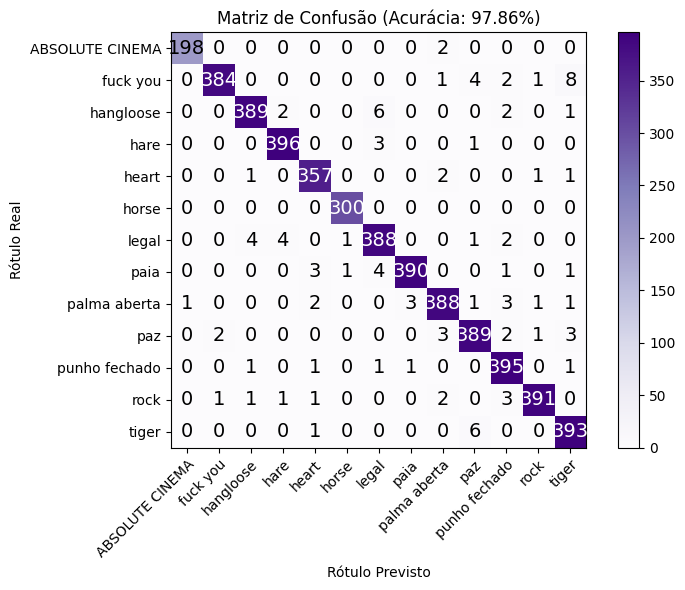

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Plotar a matriz de confusão
im = ax.imshow(cm, interpolation='nearest', cmap='Purples')
ax.figure.colorbar(im, ax=ax)

# Labels nos eixos
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=nomes_classes,
       yticklabels=nomes_classes,
       ylabel='Rótulo Real',
       xlabel='Rótulo Previsto',
       title=f'Matriz de Confusão (Acurácia: {acc:.2%})')

# Rotacionar labels do eixo X
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Anotar cada célula com o valor
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

plt.tight_layout()
plt.show()

<br>
<h2 style="color:#4A0072;">💾 Salvar o Modelo Treinado</h2>

Salvamos o modelo e o encoder de labels como arquivos `.joblib` para uso futuro (ex: predição em tempo real com a webcam):

In [47]:
# --- Salvar o modelo e o encoder ---
MODEL_SAVE_PATH = "gesture_model.joblib"
ENCODER_SAVE_PATH = "label_encoder.joblib"

joblib.dump(clf, MODEL_SAVE_PATH)
joblib.dump(label_encoder, ENCODER_SAVE_PATH)

print(f"Modelo salvo em: {MODEL_SAVE_PATH} ({os.path.getsize(MODEL_SAVE_PATH) / (1024*1024):.1f} MB)")
print(f"Encoder salvo em: {ENCODER_SAVE_PATH}")
print(f"")
print(f"Gestos que o modelo reconhece:")
for i, nome in enumerate(label_encoder.classes_):
    print(f"  {i} → {nome}")
print(f"")
print("Pronto! Agora você pode usar esses arquivos .joblib para")
print("fazer predições em tempo real com a webcam.")

Modelo salvo em: gesture_model.joblib (46.6 MB)
Encoder salvo em: label_encoder.joblib

Gestos que o modelo reconhece:
  0 → ABSOLUTE CINEMA
  1 → fuck you
  2 → hangloose
  3 → hare
  4 → heart
  5 → horse
  6 → legal
  7 → paia
  8 → palma aberta
  9 → paz
  10 → punho fechado
  11 → rock
  12 → tiger

Pronto! Agora você pode usar esses arquivos .joblib para
fazer predições em tempo real com a webcam.


<br>
<h1 style="color:#4A0072; border-bottom:3px solid #6A1B9A; padding-bottom:8px;">🎯 Reconhecimento de Gestos Customizados em Tempo Real</h1>

<h2 style="color:#4A0072;">🎯 Reconhecimento apenas com o Modelo Customizado</h2>

Nesta etapa, estamos ignorando os gestos pré-definidos do MediaPipe. Vamos usar os landmarks extraídos e passá-los **exclusivamente** pelo modelo que **acabamos de treinar** (`clf`) com o nosso CSV!

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #6A1B9A; margin:10px 0;">
💡 <b>Nota:</b> O aviso de "X does not have valid feature names" será suprimido automaticamente, pois já sabemos o motivo dele estar lá!
</div>

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

def extrair_features_para_predicao(resultado):
    '''Extrai as features no mesmo formato do CSV de treino.'''
    if not resultado.hand_landmarks:
        return None

    num_maos = len(resultado.hand_landmarks)

    # Mão 1
    hand1_name = resultado.handedness[0][0].category_name
    hand1_val = 0 if hand1_name == 'Left' else 1
    features = [num_maos, hand1_val]
    for lm in resultado.hand_landmarks[0]:
        features.extend([lm.x, lm.y, lm.z])

    # Mão 2 (ou zeros)
    if num_maos >= 2:
        hand2_name = resultado.handedness[1][0].category_name
        hand2_val = 0 if hand2_name == 'Left' else 1
        features.append(hand2_val)
        for lm in resultado.hand_landmarks[1]:
            features.extend([lm.x, lm.y, lm.z])
    else:
        features.extend([0] + [0.0] * 63)

    return np.array(features).reshape(1, -1)


# --- Configuração do reconhecedor ---
options_custom = GestureRecognizerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

# --- Webcam ---
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print('Reconhecimento apenas com modelo CUSTOMIZADO. Pressione q para sair.')

with GestureRecognizer.create_from_options(options_custom) as recognizer:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print('Falha ao capturar imagem da câmera')
            break

        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        timestamp_ms = int(cv2.getTickCount() / cv2.getTickFrequency() * 1000)

        resultado = recognizer.recognize_for_video(mp_image, timestamp_ms)

        # Desenhar landmarks
        if resultado.hand_landmarks:
            frame = desenhar_landmarks_mao(frame, resultado.hand_landmarks)

        # --- Predição Apenas Customizada (Random Forest) ---
        if resultado.hand_landmarks:
            features = extrair_features_para_predicao(resultado)
            if features is not None:
                # Predição usando o modelo Random Forest treinado com o CSV
                prediction_idx = clf.predict(features)[0]
                prediction_prob = np.max(clf.predict_proba(features))
                
                gesture_name = label_encoder.inverse_transform([prediction_idx])[0]
                
                # Cores baseadas na confiança do modelo customizado
                if prediction_prob >= 0.8:
                    cor_conf = (0, 200, 0)
                elif prediction_prob >= 0.5:
                    cor_conf = (0, 165, 255)
                else:
                    cor_conf = (0, 0, 255)

                # Desenha o nome do gesto e probabilidade
                if prediction_prob >= 0.3:  # Mostra apenas com alguma confiança
                    texto_gesto = f'{gesture_name} ({prediction_prob:.0%})'
                    (tw, th), _ = cv2.getTextSize(texto_gesto, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)
                    cv2.rectangle(frame, (10, 20 - th - 10), (10 + tw + 16, 20 + 10), COR_GESTO_FUNDO, -1)
                    cv2.putText(frame, texto_gesto, (18, 20 + 2), cv2.FONT_HERSHEY_SIMPLEX, 1.0, COR_TEXTO, 2)

                # Barra de confiança visual
                bar_width = int(prediction_prob * 200)
                cv2.rectangle(frame, (10, 40), (210, 55), (80, 80, 80), -1)
                cv2.rectangle(frame, (10, 40), (10 + bar_width, 55), cor_conf, -1)

            # Número de mãos detectadas
            n_maos = len(resultado.hand_landmarks) if resultado.hand_landmarks else 0
            cv2.putText(frame, f'Maos: {n_maos}', (10, 80),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

        cv2.imshow('Gestos Customizados', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
print('Webcam encerrada.')


<br>
<h2 style="color:#4A0072;">📝 Resumo</h2>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #6A1B9A; margin:10px 0;">
💡 <b>O que aprendemos:</b><br><br>
✅ O <b>MediaPipe Gesture Recognizer</b> combina em um único modelo: detecção de mãos, extração de <i>21 landmarks</i> e classificação de gestos.<br>
✅ Podemos <b>coletar nosso próprio dataset</b> gravando landmarks em tempo real para treinar gestos customizados.<br>
✅ O dataset suporta <b>gestos com 1 ou 2 mãos</b>, permitindo gestos como coração, triângulo, etc.<br>
✅ Treinamos um <b>Random Forest</b> do Scikit-Learn para classificar os gestos coletados.<br>
✅ Avaliamos o modelo com <b>acurácia</b>, <b>relatório de classificação</b> e <b>matriz de confusão</b>.<br>
✅ Os arquivos <b>.joblib</b> (modelo + encoder) podem ser carregados para predições em tempo real!<br>
✅ Usamos o modelo treinado para <b>reconhecer gestos customizados em tempo real</b> via webcam!
</div>